# PROJECT ANALYSIS — Heart Disease Classification
# Nhóm 14

## I. Introduction and Setup

### 1. Introduction

Bệnh tim mạch là nguyên nhân tử vong hàng đầu trên thế giới. Việc 
chẩn đoán sớm dựa trên các chỉ số lâm sàng giúp can thiệp kịp thời 
và giảm nguy cơ tử vong đáng kể.

Notebook này thực hiện toàn bộ quy trình phân tích và xây dựng mô 
hình phân loại bệnh tim (có bệnh / không có bệnh) từ dữ liệu lâm sàng 
của **920 bệnh nhân** từ 4 bệnh viện: Cleveland, Hungary, Switzerland 
và VA Long Beach.

**Dataset:** UCI Heart Disease Repository  
**Bài toán:** Binary Classification — dự đoán bệnh nhân có bệnh tim hay không  
**Metric ưu tiên:** Recall — hạn chế bỏ sót bệnh nhân có bệnh

### 2. Roadmap

| Bước | Nội dung | Người thực hiện |
|------|----------|-----------------|
| I | Introduction & Setup | Cả nhóm |
| II | Target Analysis | Quyên |
| III | Categorical Analysis | Quyên |
| IV | Distribution Analysis | Phát |
| V | Correlation Analysis | Phát |
| VI | Outlier Detection | Xuyên |
| VII | Statistical Tests | Xuyên |
| VIII | Missing Values Analysis | Xuyên |
| IX | Feature Engineering | Quyên |
| X | Train-Test Split | Phát |
| XI | Build Pipeline | Phát |
| XII | Fit & Transform | Phát |

### 3. Environment Setup and Library Import

In [512]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats

#import sklearn library
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score


In [513]:
# Cố định random state để kết quả reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 4. Data loading

In [514]:
#hàm load data set để handle error và tái sử dụng
def load_dataset(dataset_path):
    """
    Kiểm tra và lấy dữ liệu từ file csv 
    Args:
        dataset_path (str): đường dẫn file csv 
    Returns:
        pandas.dataframe: bảng dữ liệu đã được đọc
    """
    if not os.path.exists(dataset_path):
        print("Không tìm thấy file!")
        return None
    
    try: 
        df = pd.read_csv(dataset_path)
        print("Đã tải dữ liệu thành công!")
        return df
    except Exception as e:
        print(f"Đã xảy ra lỗi trong quá trình tải: {e}")
        return None
    
#define dataset path
dataset_path = "../data/dataset.csv"

#load data
df = load_dataset(dataset_path=dataset_path)

Đã tải dữ liệu thành công!


### 5. Data Overview
Đây là tập dữ liệu thô được lấy từ nguồn **[UCI Heart Disease Dataset]**

Link: https://archive.ics.uci.edu/dataset/45/heart+disease

In [515]:
#Hiển thị tổng quan về các thông tin của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...
print("Tổng quan cấu trúc dataset:")

#Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

Tổng quan cấu trúc dataset:
- Dataset có 920 dòng và 16 cột.


In [516]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
print("- Các thông tin cơ bản:")
df.info()

- Các thông tin cơ bản:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [517]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê numerical:")
display(df.describe())
print("- Các thông tin thống kê categorical:")
display(df.describe(include='object'))

- Các thông tin thống kê numerical:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


- Các thông tin thống kê categorical:


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [518]:
# Các cột numerical 
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
# Các cột categorical
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [519]:
#5 hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 6. Add target variable
Sau khi xem xét các thuộc tính của dataset, nhóm nhận thấy rằng thuộc tính 'num' của dataset là thuộc tính giúp phân loại người bệnh và không có bệnh. Nhưng giá trị của thuộc tính num này là kiểu int64 có giá trị từ **0 đến 4**, trong đó, 0 là không bệnh và 1 2 3 là có bệnh. Để phục vụ giải quyết bài toán **Classification**, nhóm quyết định thêm cột 'target' kiểu binary:
* 0: Không bệnh (num = 0)
* 1: Có bệnh (num = 1, 2, 3, 4)

Cột 'num' được giữu lại để tham khảo sau này và đúng với nguyên tắc không chỉnh sửa dữ liệu thô.

In [520]:
#Dùng hàm astype để convert tất cả dữ liệu trong cột từ bool thành int
df['target'] = (df['num'] > 0).astype(int)

#Hiển thị dữ liệu đã thêm target
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


# EDA

## II. Target Analysis

**Phân tích biến mục tiêu (Target Analysis):** Là quá trình thống kê và hình ảnh hóa để hiểu rõ đặc điểm, phân phối và tính chất của biến dự đoán trước khi xây dựng mô hình. Phân tích biến mục tiêu giúp ta xác định:
*     Dữ liệu có cân bằng hay không?
*     Chỉ số đánh giá phù hợp?
*     Các vấn đề về chất lượng dữ liệu?


Trong phần này, nhóm sử dụng biểu đồ **CountPlot** để thực hiện Target Analysis (Phân tích biến mục tiêu). Biến mục tiêu được xác định là **cột 'num'** – cột lưu trữ kết quả chẩn đoán bệnh tim của bệnh nhân. Để phù hợp với yêu cầu bài toán phân loại (có bệnh/không có bệnh), nhóm đã tiến hành nhị phân hóa cột dữ liệu này, trong đó giá trị 0 đại diện cho trạng thái **'Không bệnh'** và các giá trị từ 1 đến 4 đại diện cho trạng thái **'Có bệnh'**.

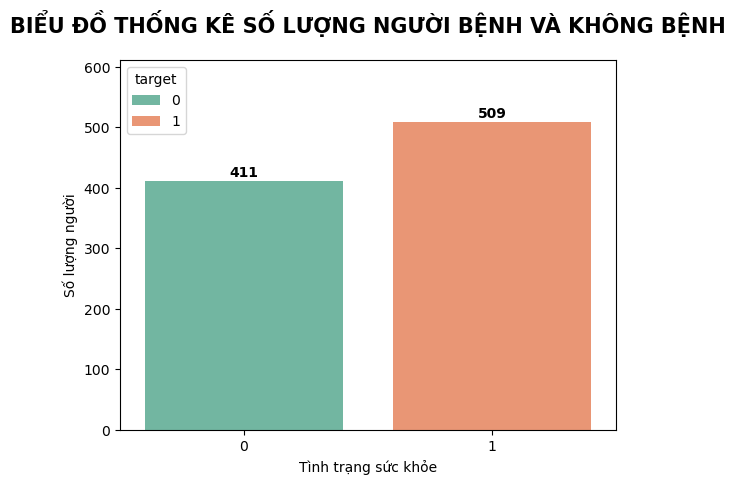

In [521]:
def plot_target_distribution(data, column='target'):
    """
    Hàm vẽ biểu đồ đếm số lượng cho biến mục tiêu.
    data: DataFrame chứa dữ liệu
    column: Tên cột muốn vẽ (mặc định là 'target')
    """
    # Vẽ biểu đồ
    ax = sns.countplot(data=data, x=column, hue=column, palette="Set2", legend=True)

    # Gắn nhãn số lượng trên đầu mỗi cột
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fontweight='bold', padding=1)

    # Thiết lập tiêu đề và các trục
        counts = data[column].value_counts()
        ax.set_ylim(0, counts.max() * 1.2)
    plt.title('BIỂU ĐỒ THỐNG KÊ SỐ LƯỢNG NGƯỜI BỆNH VÀ KHÔNG BỆNH',
              fontsize=15,
              fontweight='bold',
              pad=20)
    plt.xlabel('Tình trạng sức khỏe')
    plt.ylabel('Số lượng người')

    # Hiển thị
    plt.show()


plot_target_distribution(df)

**Nhận xét:**
* **Số lượng:** Có **411** trường hợp không mắc bệnh và **509** trường hợp mắc bệnh.
* **Độ cân bằng:** Dữ liệu có tính cân bằng cao.
* **Chiến lược đánh giá:** Ưu tiên chỉ số Recall để giảm thiểu tỷ lệ bỏ sót bệnh nhân.

**Chú thích:**
* 0:Không bệnh
* 1:Có bệnh

## III. Categorical Analysis

**Phân tích biến phân loại(Categorical Analysis)** là việc nghiên cứu các biến chứa các giá trị định tính, nhãn hoặc các nhóm hữu hạn (ví dụ: giới tính, quốc gia, loại sản phẩm) thay vì các con số liên tục. Mục tiêu chính của bước này là hiểu được sự phân phối, tần suất xuất hiện và mối quan hệ của các nhóm dữ liệu này với các biến khác.

Trong phần này nhóm sử dụng biểu đồ CountPlot để phân tích biến phân loại.

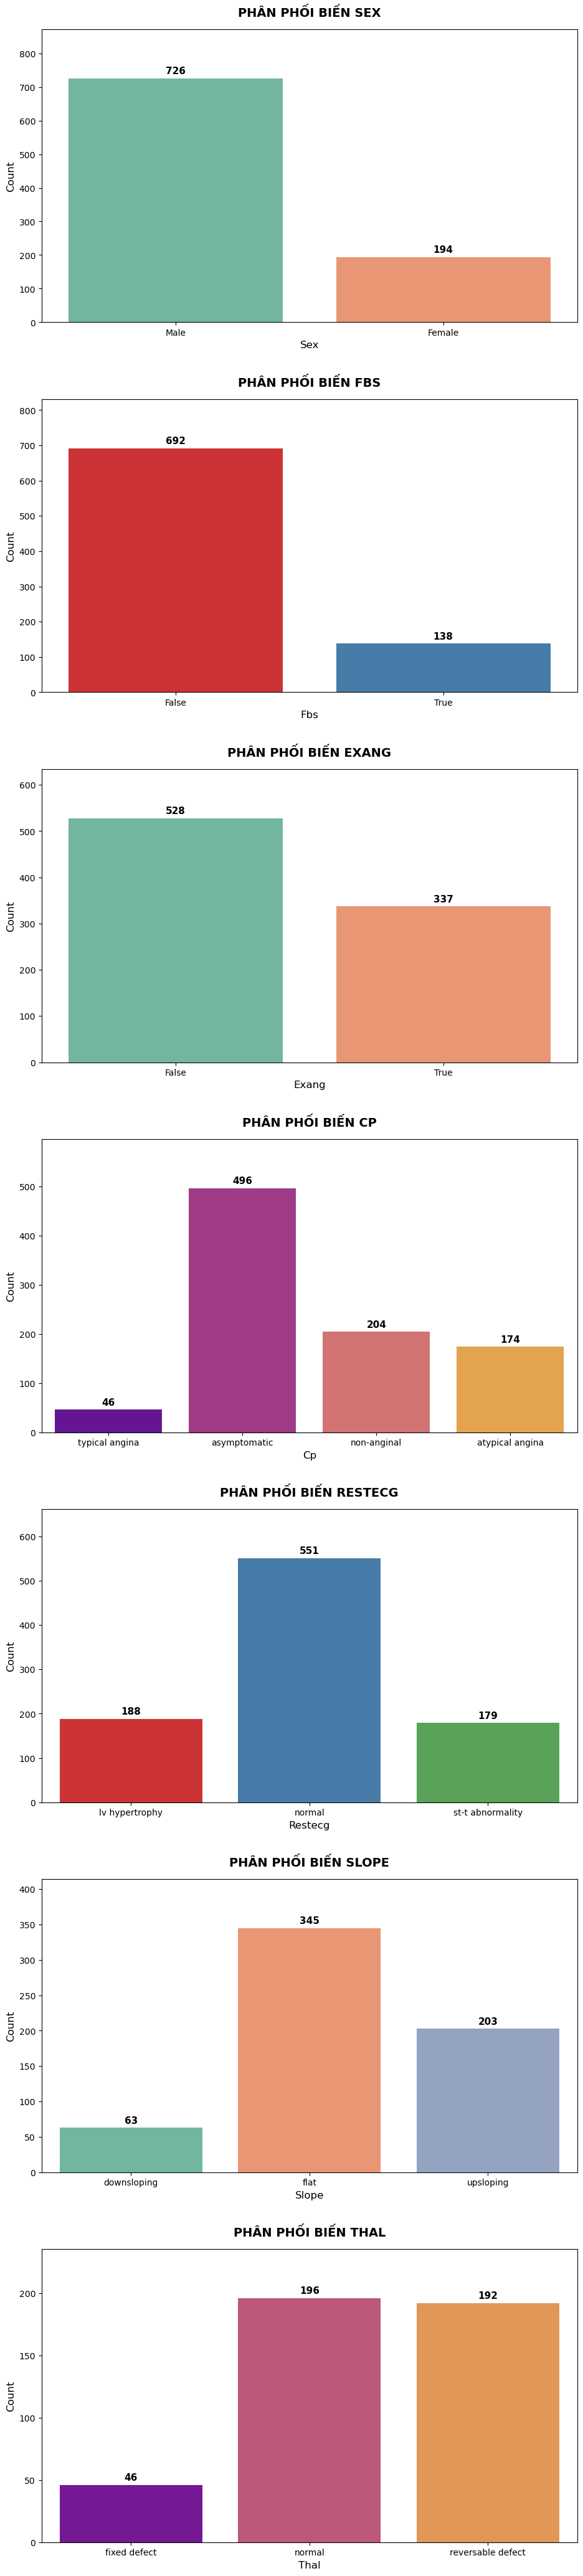

In [522]:
def plot_categorical(df, configs):
    """
    Vẽ các biểu đồ countplot cho danh sách các biến phân loại (Categorical).

    Hàm này tự động tạo ra một lưới các biểu đồ xếp dọc, gắn nhãn số lượng trên đầu mỗi cột
    và tinh chỉnh các thông số hiển thị để báo cáo trông chuyên nghiệp hơn.

    Args:
        df (pd.DataFrame): Bảng dữ liệu chứa các biến cần phân tích.
        configs (list of tuples): Danh sách cấu hình biểu đồ. Mỗi tuple bao gồm:
            (tên_cột_x, tên_cột_hue, tên_palette).
            Nếu x == hue, hàm sẽ hiểu là vẽ phân phối đơn biến.

    Returns:
        None: Hàm hiển thị biểu đồ trực tiếp bằng plt.show().
    """
    # Tạo khung hình động dựa trên số lượng biểu đồ
    fig, axes = plt.subplots(nrows=len(configs), ncols=1, figsize=(10, 6 * len(configs)))

    # Trường hợp chỉ có 1 biểu đồ, Matplotlib trả về 1 object thay vì list, cần ép về list
    if len(configs) == 1:
        axes = [axes]

    for i, (x_col, h_col, pal) in enumerate(configs):
        ax = axes[i]
        is_univariate = (x_col == h_col)

        # Vẽ biểu đồ chính
        sns.countplot(data=df, x=x_col, hue=h_col, palette=pal, ax=ax, legend=not is_univariate)

        # Gắn nhãn số lượng trên đầu mỗi cột
        for container in ax.containers:
            ax.bar_label(container, fontsize=11, fontweight='bold', padding=3)

        # Tinh chỉnh tiêu đề (Tự động nhận diện đơn biến hay đa biến)
        title_text = f'PHÂN PHỐI BIẾN {x_col.upper()}' if is_univariate else f'TỶ LỆ BỆNH THEO {x_col.upper()}'
        ax.set_title(title_text, pad=15, fontsize=14, fontweight='bold')
        ax.set_xlabel(x_col.capitalize(), fontsize=12)
        ax.set_ylabel('Count', fontsize=12)

        # Giữ chữ trên trục X nằm ngang cho dễ đọc
        if x_col in ['cp', 'restecg', 'slope', 'thal']:
            ax.tick_params(axis='x', rotation=0)

        # Chỉnh ylim để các nhãn bar_label không bị chạm đỉnh khung hình
        counts = df[x_col].value_counts()
        ax.set_ylim(0, counts.max() * 1.2)

    plt.tight_layout(pad=3.0)
    plt.show()

# --- Thực thi ---
my_configs = [
    ('sex', 'sex', 'Set2'),
    ('fbs','fbs','Set1' ),
    ('exang','exang', 'Set2'),
    ('cp', 'cp', 'plasma'),
    ('restecg','restecg','Set1' ),
    ('slope', 'slope', 'Set2'),
    ('thal','thal', 'plasma')
]

plot_categorical(df=df, configs=my_configs)

**Nhận xét:**

**-Tại biểu đồ 1:** Dữ liệu có sự mất cân bằng giới tính. Số lượng Nam giới tham gia khảo sát đông hơn rất nhiều so với Nữ giới (726 Nam so với 194 Nữ).

**-Tại biểu đồ 2:** Đau ngực loại asymptomatic (không triệu chứng) chiếm tỷ lệ cao nhất (496 ca). Các loại đau thắt ngực điển hình (typical angina) chiếm tỷ lệ thấp nhất (46 ca).

**-Tại biểu đồ 3:** Đa số người tham gia có đường huyết lúc đói dưới 120 mg/dl (692 ca). Chỉ có một nhóm nhỏ (138 ca) có chỉ số đường huyết cao (> 120 mg/dl).

**-Tại biểu đồ 4:** Số lượng người không bị đau ngực khi vận động (False - 528 ca) cao hơn đáng kể so với nhóm có bị đau ngực khi vận động (True - 337 ca).

**-Tại biểu đồ 5:** Kết quả điện tâm đồ lúc nghỉ ngơi phần lớn là normal (551 ca). Các tình trạng bất thường như lv hypertrophy hay st-t abnormality chiếm số lượng ít hơn và khá tương đồng nhau.

**-Tại biểu đồ 6:** Độ dốc của đoạn ST sau tập luyện chủ yếu là flat (345 ca) và upsloping (203 ca). Loại downsloping chiếm tỷ lệ rất thấp (63 ca).

**-Tại biểu đồ 7:** Tình trạng thiếu máu cục bộ cơ tim phổ biến nhất là normal (196 ca) và reversable (192 ca). Loại fixed defect chỉ chiếm một phần nhỏ (46 ca).

**Kết luận:** Tập dữ liệu cho thấy đối tượng khảo sát điển hình là Nam giới, có kết quả điện tâm đồ bình thường, nhưng phần lớn lại gặp tình trạng đau ngực không triệu chứng (asymptomatic). Đây là một điểm đáng lưu ý vì bệnh có thể tiến triển âm thầm mà không có biểu hiện đau thắt ngực điển hình.

## IV. Distribution Analysis

**Phân tích phân phối (Distribution Analysis)** là quan sát các giá trị trong một cột dữ liệu được phân bố như thế nào và dữ liệu được tập trung ở đâu hay dữ liệu có bị lệch hay không?
Phân tích phân phối giúp ta xác định: 
* Dữ liệu có bị lệch hay không?
* Feature nào quan trọng với mô hình?
* Feature nào không quan trọng?

Ở đây, nhóm chọn biểu đồ **KDE ()** vì biểu đồ này thể hiện sự chồng lên nhau của 2 nhóm có bệnh và không bệnh rõ ràng nhất.

Trong phần này, nhóm sẽ tập chung phân tích các cột dữ liệu là: age, trestbps, chol, thalch, oldpeak vì các cột này có dữ liệu là numerical liên tục trong 1 khoảng.

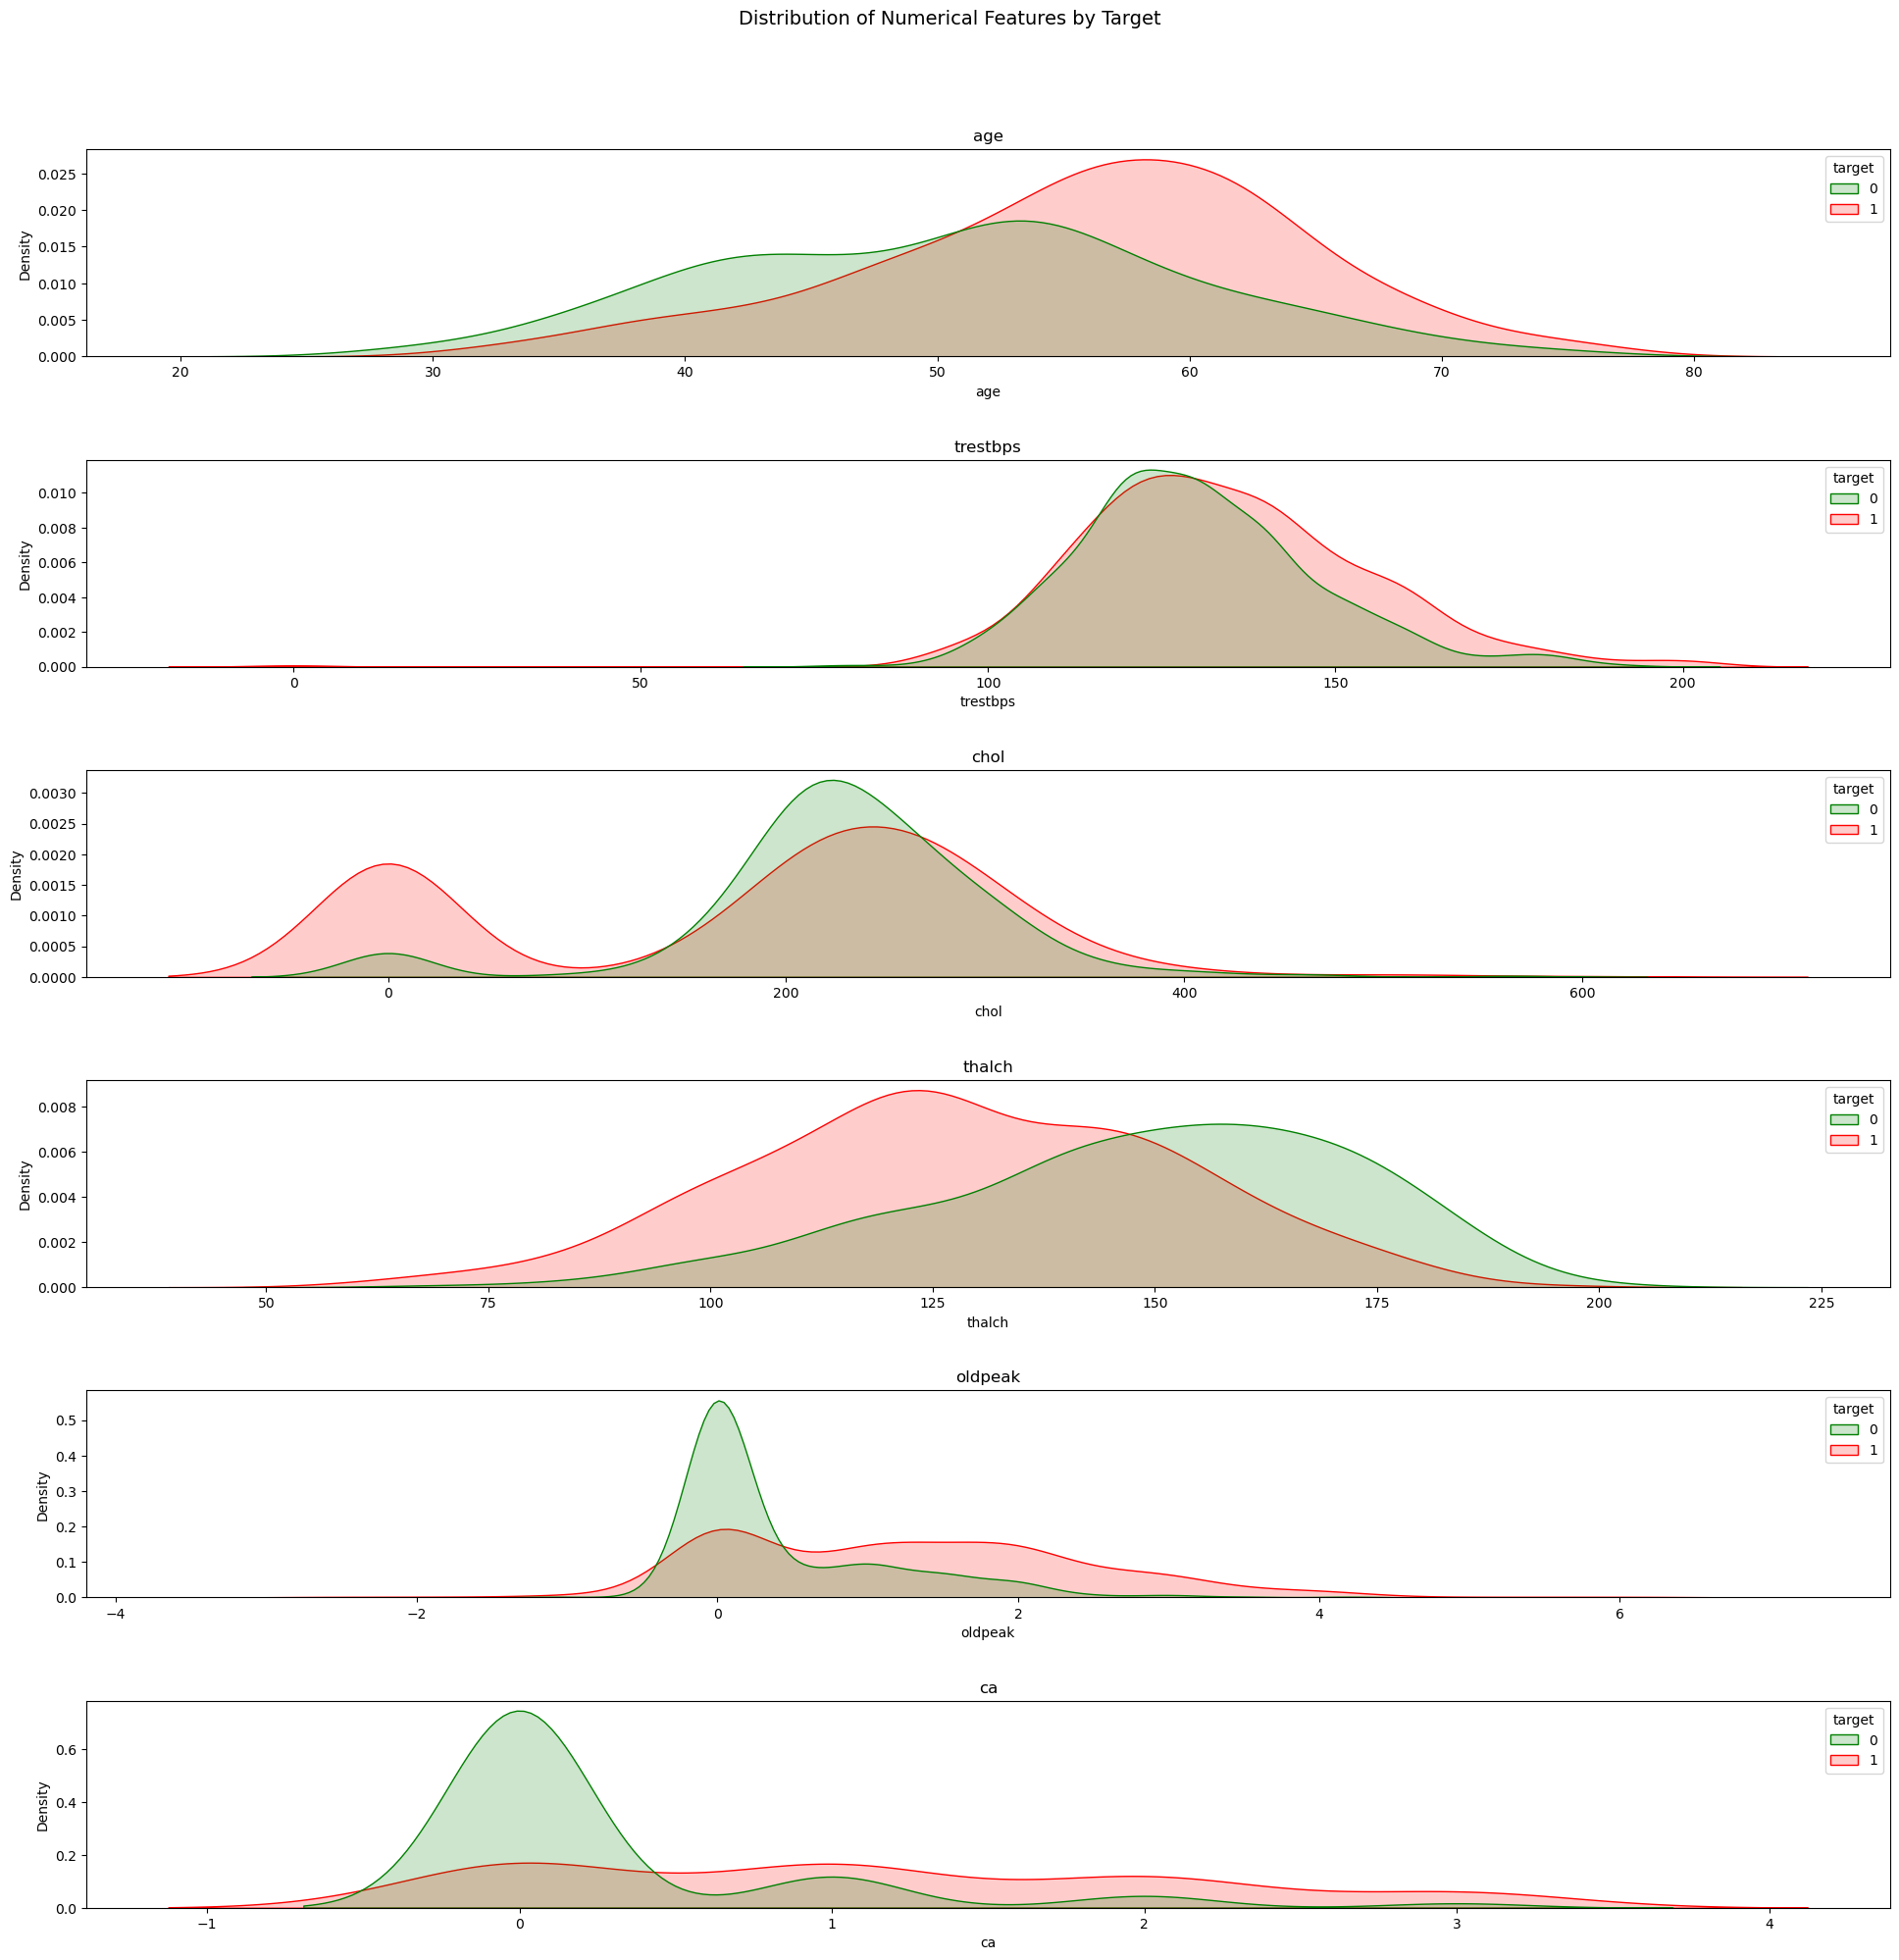

In [523]:
#hàm vẽ biểu đồ KDE cho nhiều cột trong bảng
def plot_distribution(df, num_cols, target='target'):
    """
    Vẽ biểu đồ KDE cho các cột numerical chia thành 2 đối tượng có bệnh và không bệnh bằng biến target
    Args:
        df (pandas.DataFrame): tập dữ liệu đầu vào
        cols (list): danh sách tên các cột cần vẽ biểu đồ
        target (str): tên cột target
    """
    #khung hình gồm 1 hàng và n cột mỗi cột là 1 biểu đồ, với n là số biểu đồ muốn vẽ
    fig, axes = plt.subplots(len(num_cols), 1, figsize=(20, 20))
    
    #lặp qua từng cột, i = vị trí, col = giá trị tên cột
    for i, col in enumerate(num_cols):
        #hàm vẽ biểu đồ KDE của thư viên seaborn
        sns.kdeplot(
            data=df,
            x=col,
            hue=target,
            ax=axes[i],
            fill=True,
            alpha=0.2,
            palette={0: "green", 1: "red"}
        )
        
        #Tiêu đề cho biểu đồ đang vẽ
        axes[i].set_title(col)
        
        #Nhãn của trục x
        axes[i].set_xlabel(col)
        
    plt.suptitle('Distribution of Numerical Features by Target',
                 fontsize=14, y=1.01)
    plt.tight_layout(pad=3.0)    
    
    # #Lưu hình ảnh biểu đồ
    # try:
    #     plt.savefig("../report/figures/distribution_analysis.png")
    #     print('Lưu hình ảnh thành công')
    # except Exception as e:
    #     print(f'Lỗi lưu ảnh: {e}')
        
    plt.show()

plot_distribution(df=df, num_cols=num_cols)

**Nhận xét:** 
* **age**: 
    * Nhóm không bệnh phân bố tập trung ở độ tuổi 40 - 55
    * Nhóm có bệnh phân bố tập trung ở độ tuổi 55 - 60

    Hai nhóm có chồng lên nhau nhưng dữ liệu có phần lệch hơn về phía bên phải

    -> Feature này có giá trị trung bình
* **trestbps**:

    Hai nhóm phân phối lệch phải và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **chol**:

    Hai nhóm phân phối lệch trái và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **thalch**:

    Nhóm không bệnh phân bố tập trung ở mức nhịp tim cao, từ 150 - 165

    Nhóm có bệnh phân bố tập trung ở mức nhịp tim thấp hơn, từ 120 - 135

    Hai nhóm tách biệt nhau khá rõ ràng và ít bị chồng chéo, điểm giao cắt rõ nét ở khoảng 145 - 150.

    -> Feature này có giá trị phân loại cao (mạnh nhất).
* **oldpeak**:

    Nhóm không bệnh phân bố tập trung rất cao tại mốc 0.

    Nhóm có bệnh phân bố trải dài hơn, tạo thành các khoảng tập trung ở gần mốc 0 và từ 1.0 đến 2.5.

    Hai nhóm có chồng lên nhau ở mốc 0 nhưng hình dáng khác biệt rõ rệt. Dữ liệu của nhóm có bệnh có phần đuôi dài, lệch hẳn về phía bên phải (lên tới mức 4.0 trở lên).

    -> Feature này có giá trị cao.
    
**=> Tóm lại**, trong các đặc trưng trên, **thalch** và **oldpeak** mang lại giá trị phân loại mạnh nhất. **age** có giá trị ở mức trung bình. Cần tập trung vào các feature này, đồng thời cân nhắc loại bỏ các feature yếu (trestbps, chol) để tránh nhiễu và tối ưu hiệu suất mô hình.


## V. Correlation Analysis

**Phân tích tương quan (Correlation Analysis)** là phương pháp thống kê đánh giá mức độ liên quan giữa 2 hoặc nhiều biến số. 

Phân tích tương quan giúp ta xác định:

- Feature nào liên quan mạnh nhất đến bệnh tim?
- Có 2 feature nào mang thông tin trùng lặp nhau không?
- Feature nào nên ưu tiên khi xây dựng mô hình?

Ở đây, nhóm chọn biểu đồ **Heatmap** vì biểu đồ này thể hiện
toàn bộ mối quan hệ giữa tất cả các feature cùng lúc thông qua
màu sắc — màu càng đậm thì tương quan càng mạnh.

Hệ số tương quan có giá trị từ -1 đến 1, trong đó 1 là
tương quan thuận hoàn toàn, 0 là không có tương quan, và -1
là tương quan nghịch hoàn toàn.

Trong phần này, nhóm sẽ encode các cột categorical sang dạng số
trước khi tính tương quan vì hệ số Pearson chỉ tính được trên dữ
liệu số. Việc encode chỉ dùng trong section này, không thay đổi
dữ liệu gốc.

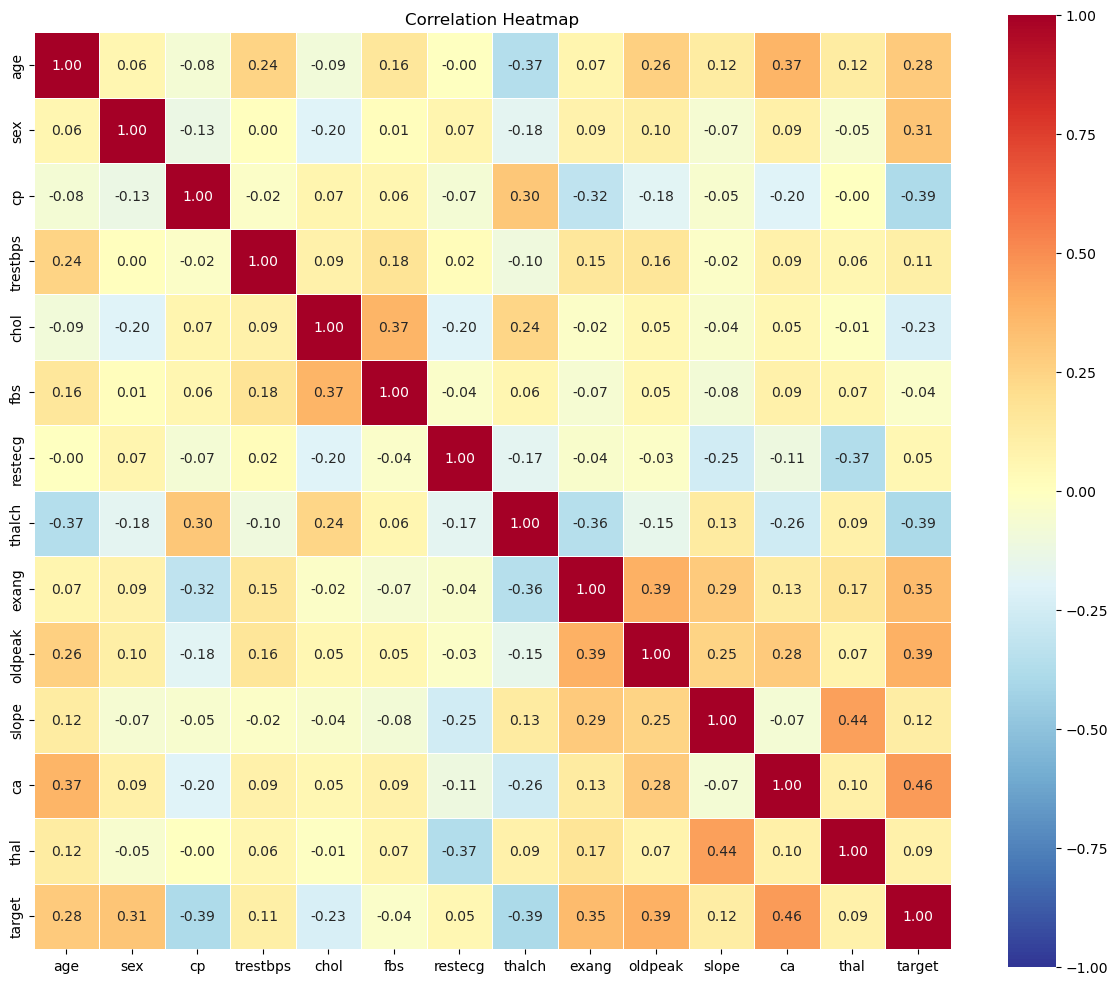

tương quan các cột với target theo độ mạnh:
ca          0.46
thalch     -0.39
oldpeak     0.39
cp         -0.39
exang       0.35
sex         0.31
age         0.28
chol       -0.23
slope       0.12
trestbps    0.11
thal        0.09
restecg     0.05
fbs        -0.04
Name: target, dtype: float64


In [524]:
def encode_categorical(df, cat_cols):
    """
    Encode các categorical feature
    Args:
        df (pandas.DataFrame): tập dữ liệu đầu vào
        cat_cols (list): danh sách các cột là categorical
    Returns:
        (pandas.DataFrame): tập dữ liệu dã được encode
    """
    #tạo bản sao của df để encode mà không làm thay đổi dữ liệu gốc
    df_encoded = df.copy()
    
    #dùng Categorical().codes để encode thành số tự động
    for col in cat_cols:
        df_encoded[col] = pd.Categorical(df_encoded[col]).codes
    
    return df_encoded

def plot_correlation(df, target='target'):
    """
    Vẽ biểu đồ heatmap.
    Args:
        df (pandas.DataFrame): tập dữ liệu đầu vào
        target (str): tên cột target
    """

    #encode các cột categorical để tính hệ số pearson
    df_encoded = encode_categorical(df, cat_cols=cat_cols)
    
    #trong biểu đồ heatmap này các cột id, dataset không có ý nghĩa so sánh và cột num đã được chuyển thành target, nên không cần dùng các cột này
    df_encoded = df_encoded.drop(columns=['id', 'dataset', 'num'])
    
    #tính ma trận tương quan
    corr_matrix = df_encoded.corr()
    
    #vẽ heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,          
        fmt='.2f',           
        cmap='RdYlBu_r',     
        center=0,            
        vmin=-1, vmax=1,     
        linewidths=0.5,      
        square=True          
    )
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
    
    print('tương quan các cột với target theo độ mạnh:')
    print(corr_matrix[target].drop(target).sort_values(key=abs,ascending=False).round(2))
    
plot_correlation(df)

**Nhận xét:**
* Các feature tương quan mạnh với target (|r| > 0.3):

| Feature | Hệ số | Ý nghĩa |
|---|---|---|
| ca | +0.46 | Số mạch vành bị tắc càng nhiều -> nguy cơ bệnh càng cao |
| thalch | -0.39 | Nhịp tim tối đa càng thấp -> nguy cơ bệnh càng cao |
| oldpeak | +0.39 | ST depression càng cao -> nguy cơ bệnh càng cao |
| cp | -0.39 | Loại đau ngực có liên quan rõ đến bệnh tim |
| exang | +0.35 | Đau ngực khi gắng sức -> dấu hiệu rõ của bệnh tim |
| sex | +0.31 | Giới tính có ảnh hưởng đến nguy cơ bệnh tim |

* Những feature còn lại có tương quan yếu hoặc gần như không tương quan với target

* Những feature có tương quan mạnh với nhau:

| Cặp Feature | Hệ số | Ý nghĩa |
|---|---|---|
| slope vs thal | +0.44 | Khá trùng lặp |
| exang vs oldpeak | +0.39 | Có liên quan nhau |
| chol vs fbs | +0.37 | Cholesterol cao đi đôi với đường huyết cao |
| ca vs age | +0.37 | Người lớn tuổi -> mạch vành dễ bị tắc hơn |
| thalch vs age | -0.37 | Người lớn tuổi -> nhịp tim tối đa thấp hơn |
| thal vs restecg | -0.37 | Kết quả thalassemia liên quan đến ECG |
| thalch vs exang | -0.36 | Nhịp tim tối đa thấp đi đôi với đau ngực khi gắng sức |
| exang vs cp | -0.32 | Loại đau ngực liên quan đến đau khi gắng sức |

**=> Tóm lại,**

- Các feature tương quan mạnh với target có: ca, thalch, oldpeak, cp, exang và sex
-> ưu tiên giữ lại các feature này.

- Các feature tương quan yếu có: thal, restecg và fbs
-> cân nhắc bỏ bớt

- Các cặp feature có tương quan mạnh có: slope và thal, exang và oldpeak
-> cân nhắc bỏ bớt 1 trong mỗi cặp

## VI. Outlier-Analysis

- Mục tiêu: phát hiện các giá trị bất thường (outliers) trong dataset. Outliers có thể:  dữ liệu thật (bệnh nhân có chỉ số rất cao) hay lỗi nhập liệu / dữ liệu thiếu. Nếu không kiểm tra outlier, các giá trị cực đoan có thể ảnh hưởng đến việc phân tích thống kê và mô hình machine learning.

- Các biến y tế như: age, trestbps, chol, thalch , oldpeak . Có thể chứa các giá trị cực đoan hoặc lỗi nhập liệu. Nếu không phát hiện các giá trị này, chúng có thể làm **sai lệch kết quả phân tích thống kê và mô hình machine learning**. Vì vậy cần thực hiện **Outlier Analysis** trước khi tiếp tục các bước tiếp theo.

In [525]:
# Hàm vẽ Boxplot :  Boxplot giúp trực quan hóa phân bố dữ liệu và dễ dàng nhận ra các điểm nằm ngoài phạm vi bình thường.
def plot_boxplot(df, column):

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [526]:
# Phát hiện Outlier bằng phương pháp IQR : Phương pháp **Interquartile Range (IQR)** được sử dụng để xác định các giá trị bất thường.
def detect_outlier(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\n===== Outlier in {column} =====")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))

    return outliers

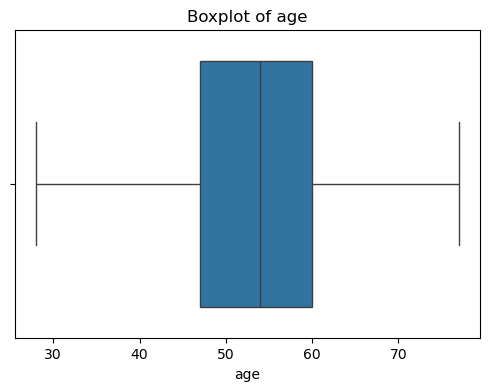


===== Outlier in age =====
Lower bound: 27.5
Upper bound: 79.5
Number of outliers: 0


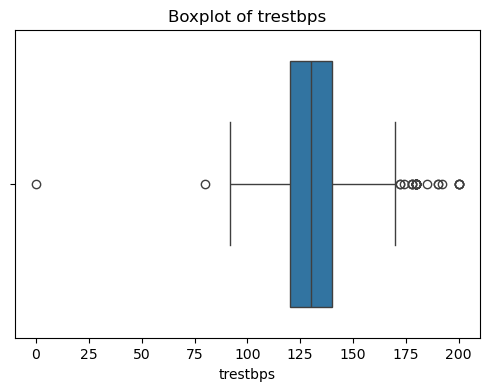


===== Outlier in trestbps =====
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 28


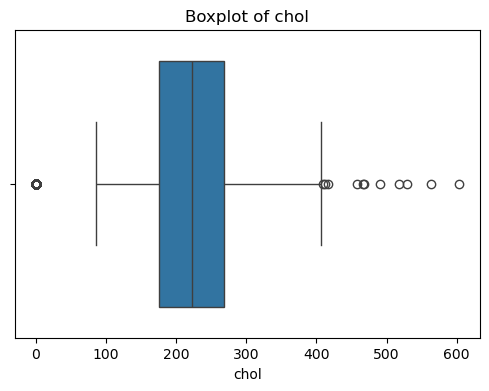


===== Outlier in chol =====
Lower bound: 35.5
Upper bound: 407.5
Number of outliers: 183


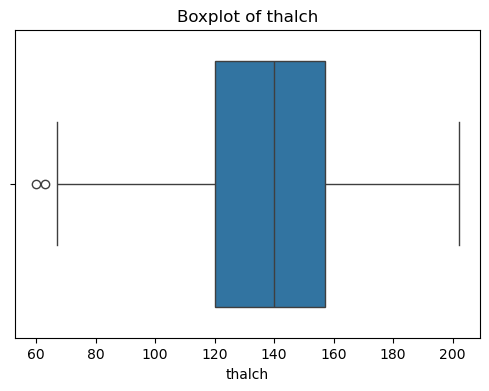


===== Outlier in thalch =====
Lower bound: 64.5
Upper bound: 212.5
Number of outliers: 2


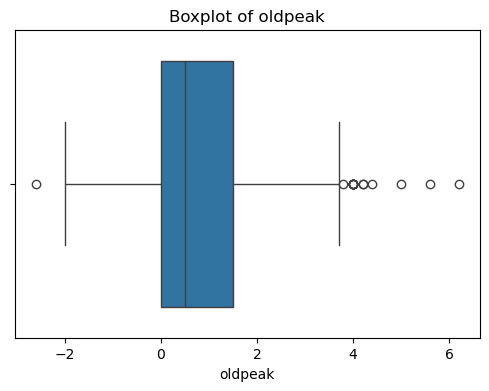


===== Outlier in oldpeak =====
Lower bound: -2.25
Upper bound: 3.75
Number of outliers: 16


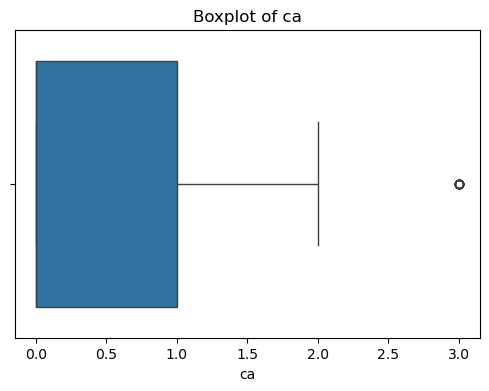


===== Outlier in ca =====
Lower bound: -1.5
Upper bound: 2.5
Number of outliers: 20


In [527]:
# Phân tích Outlier cho từng biến:  Vẽ boxplot và Tính số lượng outlier bằng IQR
for col in num_cols:
    plot_boxplot(df, col)
    detect_outlier(df, col)

In [528]:
# Kiểm tra giá trị cực trị (Min và Max): Sau khi phát hiện outlier, chúng ta cần kiểm tra **giá trị nhỏ nhất và lớn nhất** để xác định: Outlier là dữ liệu thật hay lỗi nhập liệu
for col in num_cols:
    print(f"\nColumn: {col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


Column: age
Min: 28
Max: 77

Column: trestbps
Min: 0.0
Max: 200.0

Column: chol
Min: 0.0
Max: 603.0

Column: thalch
Min: 60.0
Max: 202.0

Column: oldpeak
Min: -2.6
Max: 6.2

Column: ca
Min: 0.0
Max: 3.0


Nhận xét Outlier:
Kết quả cho thấy:
Cholesterol có nhiều outlier hơn các biến khác.
Một số giá trị như chol = 0 hoặc trestbps = 0 không hợp lý về mặt y học.

Ví dụ:
- Cholesterol không thể bằng 0
- Huyết áp không thể bằng 0

Do đó các giá trị này có thể là lỗi nhập liệu hoặc missing values.

Xử lý dữ liệu bất thường các giá trị bằng 0 trong các cột: "age", "trestbps", "chol", "thalch", "oldpeak". Được xem là dữ liệu không hợp lệ. Thay vì xóa dữ liệu, chúng ta chuyển các giá trị này thành missing values (NaN) để xử lý ở bước preprocessing.

In [529]:
df["chol"] = df["chol"].replace(0, np.nan)
df["trestbps"] = df["trestbps"].replace(0, np.nan)
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [530]:
#Kết quả sau khi xử lý giá trị 0 thành NaN
for col in num_cols:
    detect_outlier(df, col)


===== Outlier in age =====
Lower bound: 27.5
Upper bound: 79.5
Number of outliers: 0

===== Outlier in trestbps =====
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 27

===== Outlier in chol =====
Lower bound: 109.875
Upper bound: 376.875
Number of outliers: 23

===== Outlier in thalch =====
Lower bound: 64.5
Upper bound: 212.5
Number of outliers: 2

===== Outlier in oldpeak =====
Lower bound: -2.25
Upper bound: 3.75
Number of outliers: 16

===== Outlier in ca =====
Lower bound: -1.5
Upper bound: 2.5
Number of outliers: 20


## VII. Statistical Tests

Mục tiêu: Sau khi khám phá dữ liệu (EDA) và phân tích outlier, bước tiếp theo là thực hiện kiểm định thống kê để xem liệu một số biến có liên quan đến bệnh tim hay không. Trong dataset này, biến `num` thể hiện tình trạng bệnh tim:

- `0` : không có bệnh tim
- `1,2,3,4` : có bệnh tim

Để đơn giản hóa phân tích, chúng ta chuyển biến này thành biến nhị phân:

- `0` : không bệnh
- `1` : có bệnh

Sau đó kiểm định xem tuổi (age) có khác biệt giữa hai nhóm này hay không.

In [531]:
df['target'].value_counts()

target
1    509
0    411
Name: count, dtype: int64

Tách dữ liệu thành hai nhóm:
Để thực hiện kiểm định thống kê, chúng ta chia dữ liệu thành: Nhóm có bệnh tim và  Nhóm không có bệnh tim.
Sau đó so sánh biến age giữa hai nhóm này

In [532]:
group_disease = df[df["target"] == 1]["age"]
group_no_disease = df[df["target"] == 0]["age"]

print("Số bệnh nhân có bệnh tim:", len(group_disease))
print("Số bệnh nhân không bệnh tim:", len(group_no_disease))

Số bệnh nhân có bệnh tim: 509
Số bệnh nhân không bệnh tim: 411


Chọn phương pháp kiểm định: Dữ liệu y tế thường không tuân theo phân phối chuẩn. Vì vậy thay vì dùng T-test, chúng ta sử dụng:Mann–Whitney U Test Đây là kiểm định phi tham số dùng để so sánh hai nhóm độc lập.

In [533]:
stat, p_value = stats.mannwhitneyu(group_disease, group_no_disease)

print("Statistic:", stat)
print("P-value:", p_value)

Statistic: 139869.0
P-value: 1.288873276620284e-18


Giả thuyết kiểm định:

 H0 (Null Hypothesis):Không có sự khác biệt về tuổi giữa nhóm có bệnh tim và không bệnh tim.
 
 H1 (Alternative Hypothesis): Có sự khác biệt về tuổi giữa hai nhóm.

In [534]:
alpha = 0.05

print("\n===== Kết luận =====")

if p_value < alpha:
    print("Bác bỏ H0")
    print("→ Tuổi có ảnh hưởng đến nguy cơ bệnh tim")
else:
    print("Không đủ bằng chứng để bác bỏ H0")


===== Kết luận =====
Bác bỏ H0
→ Tuổi có ảnh hưởng đến nguy cơ bệnh tim


Nhận xét:
 Kết quả kiểm định cho thấy liệu tuổi có liên quan đến bệnh tim hay không.
  Nếu p-value < 0.05:
  → Có sự khác biệt có ý nghĩa thống kê giữa hai nhóm.
  Điều này cho thấy tuổi có thể là một yếu tố liên quan đến nguy cơ mắc bệnh tim.
Ngược lại nếu p-value ≥ 0.05:
→ Không có đủ bằng chứng thống kê để kết luận tuổi ảnh hưởng đến bệnh tim.

# Preprocessing

## VIII. Missing Values Analysis

### 1. Phân tích missing values

#### 1.1 Thống kê missing values

In [535]:
missing_summary = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

missing_summary

,column,missing_count,missing_percent
ca,ca,611,66.413043
thal,thal,486,52.826087
slope,slope,309,33.586957
chol,chol,202,21.956522
fbs,fbs,90,9.782609
oldpeak,oldpeak,62,6.739130
trestbps,trestbps,60,6.521739
thalch,thalch,55,5.978261
exang,exang,55,5.978261
restecg,restecg,2,0.217391


#### 1.2. Visualize missing

**Bar chart tỷ lệ missing**

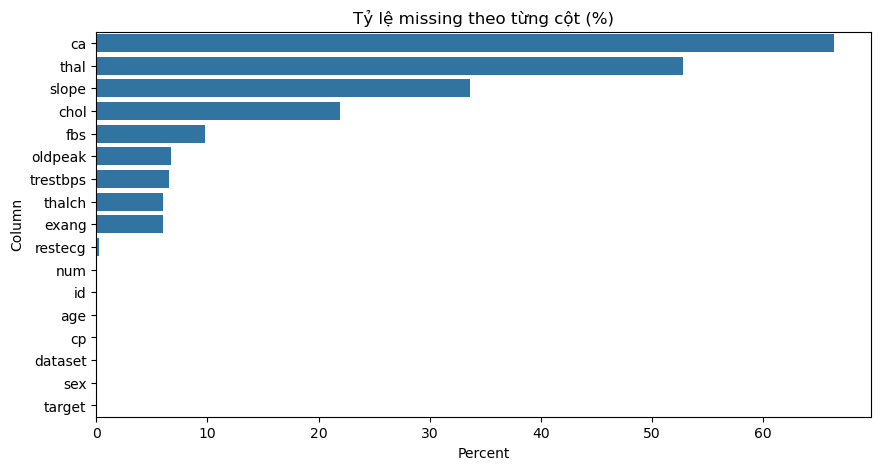

In [536]:
plt.figure(figsize=(10,5))
sns.barplot(x='missing_percent', y='column', data=missing_summary)
plt.title('Tỷ lệ missing theo từng cột (%)')
plt.xlabel('Percent')
plt.ylabel('Column')
plt.show()

**Heatmap missing pattern**

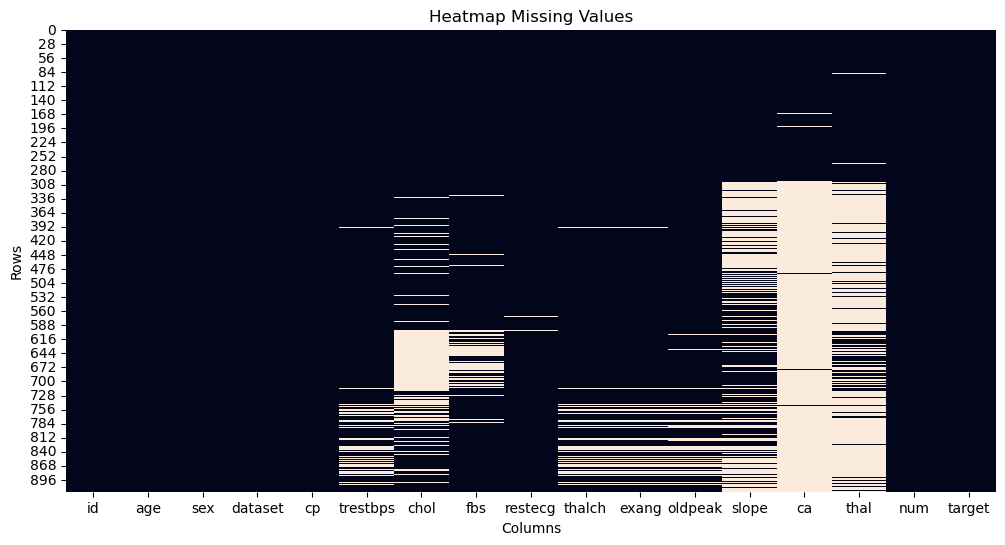

In [537]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Heatmap Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

#### 1.3. Kiểm tra nhanh các trường hợp quan trọng

In [538]:
# tổng số missing toàn dataset
total_missing = df.isnull().sum().sum()
print("Tổng số giá trị thiếu:", total_missing)

# cột nào > 50% missing
high_missing_cols = missing_summary[missing_summary['missing_percent'] > 50]
print("Cột có >50% missing:\n", high_missing_cols)

Tổng số giá trị thiếu: 1932
Cột có >50% missing:
      column  missing_count  missing_percent
ca       ca            611        66.413043
thal   thal            486        52.826087


#### 1.4.Nhận Xét

Nhận xét :
- Dataset có tình trạng thiếu dữ liệu khá rõ rệt, đặc biệt ở một số cột quan trọng.
- Hai cột ca và thal có tỷ lệ thiếu vượt quá 50%, điều này ảnh hưởng trực tiếp đến chất lượng mô hình nếu không xử lý.
- Một số cột khác như slope (33.6%), fbs (9.8%), oldpeak (6.7%), trestbps (6.4%) cũng có tỷ lệ thiếu đáng kể, cần cân nhắc phương pháp điền giá trị hoặc loại bỏ.
- Các cột còn lại nhìn chung khá đầy đủ, tỷ lệ thiếu thấp (<10%), có thể xử lý đơn giản.
- Không thấy pattern thiếu dữ liệu theo hàng, nghĩa là dữ liệu bị thiếu mang tính ngẫu nhiên.

### 2. Quyết định chiến lược

Dựa trên kết quả KDE (Section IV) và Boxplot (Section VI):
- Các cột số có outlier hoặc phân phối lệch → dùng **Median** để 
  tránh bị kéo lệch bởi các giá trị cực đoan.
- Các cột categorical là nominal (không có thứ tự tự nhiên) → dùng 
  **OneHotEncoder** để tránh model hiểu sai quan hệ giữa các nhãn.
- Các cột sex, fbs, exang tuy nhìn có vẻ nhị phân nhưng trong dataset 
  đang ở dạng string (Male/Female, TRUE/FALSE) → xử lý như categorical.

| Cột | Imputer Strategy | Encoding | Lý do |
|---|---|---|---|
| chol | Median | StandardScaler | Outlier lớn ~500+ đã xác nhận ở Section VI |
| trestbps | Median | StandardScaler | Giá trị 0 bất hợp lý đã replace thành NaN ở Section VI |
| oldpeak | Median | StandardScaler | Phân phối lệch phải rõ ràng (Section IV) |
| age, thalch, ca | Median | StandardScaler | Phân phối hơi lệch, median ổn định hơn |
| cp, slope, thal, restecg | Most_frequent | OneHotEncoder | Nominal — không có thứ tự tự nhiên |
| sex, fbs, exang | Most_frequent | OneHotEncoder | Đang là string, không phải 0/1 |

**Tóm lại**

Toàn bộ 13 cột input được chia thành 2 nhóm xử lý:
- **8 cột numerical** (bao gồm 2 cột FE): Imputer(median) → StandardScaler
- **7 cột categorical**: Imputer(most_frequent) → OneHotEncoder

Quyết định này là cơ sở để build Pipeline ở Section XI.

## IX.Feature Engineering

### 1.Tạo các Feature mới

Giải thích lí do tạo ra các feature này:

**Feature 1: heart_rate_ratio — Tỷ lệ nhịp tim đạt được**

Công thức Karvonen trong y học: nhịp tim tối đa lý thuyết của một người = 220 trừ tuổi. Đây là ngưỡng tối đa tim có thể đập được. Khi bác sĩ làm stress test (kiểm tra gắng sức), họ theo dõi bệnh nhân có đạt được bao nhiêu % ngưỡng tối đa này. Ý nghĩa lâm sàng: người đạt < 85% ngưỡng tối đa trong stress test có nguy cơ bệnh tim mạch cao hơn đáng kể. Bác sĩ gọi đây là 'chronotropic incompetence'. Feature heart_rate_ratio chính là cách đo tỷ lệ này.

**Cách tính:** Lấy giá trị thalach chia cho (220 trừ age). Kết quả là số thực từ 0 đến ~1.1.

**Tại sao tốt hơn dùng riêng thalach?**
 Bởi vì thalach=150 có ý nghĩa khác nhau hoàn toàn tùy theo tuổi. Người 30 tuổi có thalach=150 đang đạt 75% khả năng tối đa (150/200). Người 70 tuổi có thalach=150 đang đạt 100% (150/150) — xuất sắc. Feature mới nắm bắt được sự phụ thuộc phi tuyến này.

**Feature 2: age_risk_group — Nhóm nguy cơ theo tuổi**

Nguy cơ bệnh tim mạch không tăng tuyến tính (đều đặn) theo tuổi. Nghiên cứu lâm sàng cho thấy nguy cơ tăng vọt tại các ngưỡng nhất định: sau 40 tuổi, sau 50 tuổi, và sau 60 tuổi. Đây là hiện tượng 'threshold effect' — ngưỡng nguy hiểm. Nếu dùng age trực tiếp, model tuyến tính (như Logistic Regression) khó nhận ra được các ngưỡng phi tuyến này. Nhóm hóa giúp 'biến đổi' mối quan hệ phi tuyến thành dạng mà model có thể học được

**Cách tính:** Phân nhóm age thành 4 nhóm: 0–40 (nhóm 0), 40–50 (nhóm 1), 50–60 (nhóm 2), 60+ (nhóm 3). Kết quả là số nguyên 0–3 thể hiện mức nguy cơ tăng dần.



In [539]:
def feature_engineering(df):
    """
    Thực hiện tạo các đặc trưng mới dựa trên kiến thức y sinh.
    Args:
        df (pandas.DataFrame): tập dữ liệu đầu vào
    Returns:    
        pandas.DataFrame: tập dữ liệu sau khi đã được tạo đặc trưng mới
    """
    # Bước 1: Luôn copy dữ liệu gốc
    df_fe = df.copy()

    # Hàm nhỏ 1: Tính toán heart_rate_ratio
    def create_heart_rate_ratio(data):
        # Công thức Karvonen: thalch / (220 - age)
        return data['thalch'] / (220 - data['age'])

    # Hàm nhỏ 2: Phân nhóm tuổi nguy cơ
    def create_age_risk_group(data):
        bins = [0, 40, 50, 60, np.inf]
        labels = [0, 1, 2, 3]
        # Ép kiểu về int để Pipeline không lỗi
        return pd.cut(data['age'], bins=bins, labels=labels).astype(int)

    # Bước 2: Gọi các hàm nhỏ để gán giá trị vào DataFrame
    df_fe['heart_rate_ratio'] = create_heart_rate_ratio(df_fe)
    df_fe['age_risk_group'] = create_age_risk_group(df_fe)

    return df_fe

### 2. Visualize (Trực quan hóa)

---VẼ BIỂU ĐỒ 1 (BOXPLOT) ---


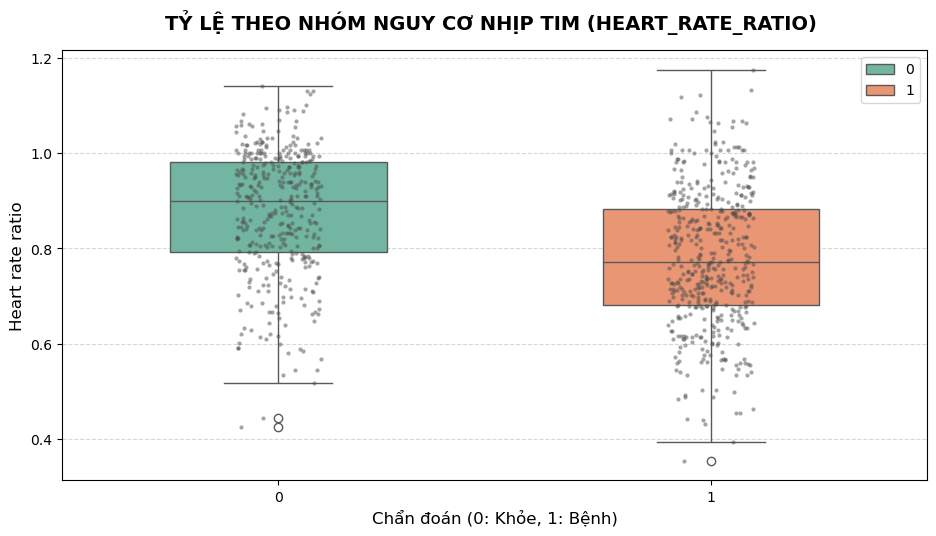

--- VẼ BIỂU ĐỒ 2 (STACKED BAR) ---


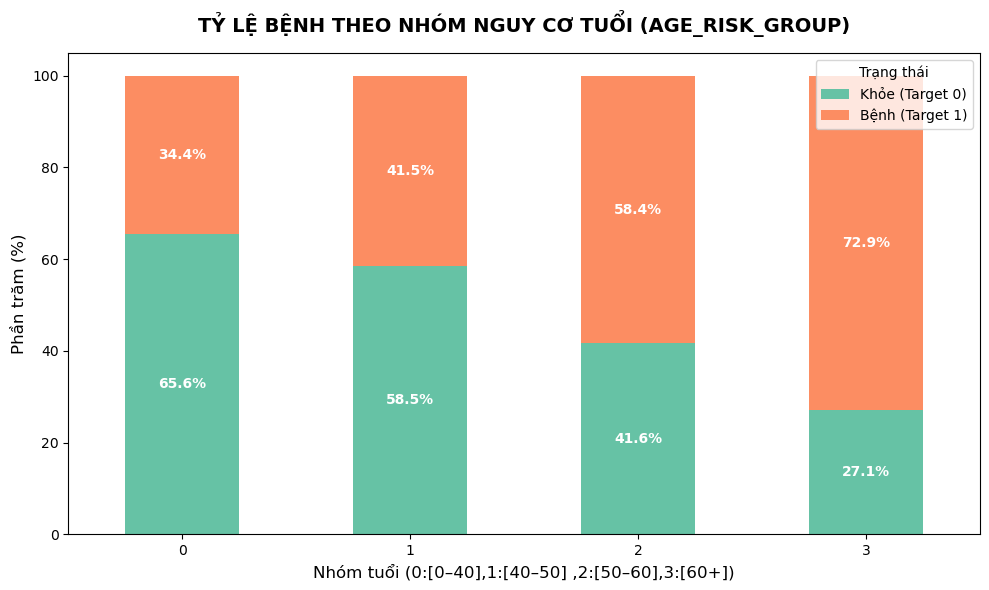

In [540]:
def plot_boxplot_heart_rate(df, configs):
    """
    Vẽ biểu đồ Boxplot kết hợp Stripplot để so sánh biến số theo Target.

    Args:
        df (pd.DataFrame): Bảng dữ liệu đã có feature mới.
        configs (list of tuples): Danh sách (tên_cột_số, tên_palette).
    """
    # Tạo khung hình dựa trên số lượng cấu hình truyền vào
    fig, axes = plt.subplots(nrows=len(configs), ncols=1, figsize=(10, 6 * len(configs)))

    # Ép về list nếu chỉ có 1 biểu đồ để vòng lặp for không bị lỗi
    if len(configs) == 1:
        axes = [axes]

    for i, (col, pal) in enumerate(configs):
        ax = axes[i]

        # 1. Vẽ Boxplot làm nền (thể hiện tứ phân vị và trung vị)
        sns.boxplot(data=df, x='target', y=col, palette=pal, hue='target', ax=ax, width=0.5)

        # 2. Vẽ thêm Stripplot (hiển thị từng chấm dữ liệu thực tế)
        sns.stripplot(data=df, x='target', y=col, color=".3", size=3, alpha=0.5, ax=ax)

        # 3. Tinh chỉnh
        ax.set_title(f'TỶ LỆ THEO NHÓM NGUY CƠ NHỊP TIM ({col.upper()}) ', pad=15, fontsize=14, fontweight='bold')
        ax.set_xlabel('Chẩn đoán (0: Khỏe, 1: Bệnh)', fontsize=12)
        ax.set_ylabel(col.replace('_', ' ').capitalize(), fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(pad=3.0)
    plt.show()


def plot_stacked_age_risk(df, col):
    """
    Vẽ biểu đồ Stacked Bar Chart cho age_risk_group .
    """
    # 1. Tính toán tỷ lệ % (Màu xanh = khỏe, Màu cam/đỏ = bệnh)
    data_pct = pd.crosstab(df[col], df['target'], normalize='index') * 100

    # 2. Vẽ biểu đồ cột chồng
    ax = data_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62'])

    # 3. Tinh chỉnh
    plt.title(f'TỶ LỆ BỆNH THEO NHÓM NGUY CƠ TUỔI ({col.upper()})', pad=15, fontsize=14, fontweight='bold')
    plt.xlabel('Nhóm tuổi (0:[0–40],1:[40–50] ,2:[50–60],3:[60+])', fontsize=12)
    plt.ylabel('Phần trăm (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(['Khỏe (Target 0)', 'Bệnh (Target 1)'], loc='upper right', title='Trạng thái')

    # Gắn nhãn số % lên cột
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center', color='white',
                    fontweight='bold')

    plt.tight_layout()
    plt.show()


####################
df_fe = feature_engineering(df)

# BIỂU ĐỒ 1: Boxplot cho biến số (heart_rate_ratio)
print("---VẼ BIỂU ĐỒ 1 (BOXPLOT) ---")
my_heart_rate_configs = [('heart_rate_ratio', 'Set2')]
plot_boxplot_heart_rate(df=df_fe, configs=my_heart_rate_configs)

# BIỂU ĐỒ 2: Stacked Bar cho biến phân loại (age_risk_group)
print("--- VẼ BIỂU ĐỒ 2 (STACKED BAR) ---")
plot_stacked_age_risk(df=df_fe, col='age_risk_group')


**Biểu đồ 1:**

**Xu hướng chính:** Có sự khác biệt rõ rệt về phân phối chỉ số giữa hai nhóm. Nhóm khỏe mạnh (Target 0 - Màu xanh) có hộp nằm ở vị trí cao hơn hẳn so với nhóm bệnh lý (Target 1 - Màu cam).

**Giá trị trung vị:** Nhóm khỏe mạnh có trung vị nhịp tim đạt được xấp xỉ 0.9 (90% ngưỡng tối đa), trong khi nhóm bệnh lý chỉ đạt khoảng 0.78.

**Ý nghĩa y sinh:** Kết quả này chứng minh rằng bệnh nhân tim mạch thường gặp tình trạng "suy giảm khả năng đáp ứng nhịp tim" khi gắng sức.

**Kết luận:** Đặc trưng này giúp mô hình phân tách tốt hai nhóm đối tượng vì dải giá trị của chúng ít bị chồng lấn đáng kể ở phần lõi (hộp).

**Biểu đồ 2:**

**Xu hướng chính:** Tỷ lệ phần trăm bệnh nhân (màu cam) có xu hướng tăng dần đều theo các nhóm tuổi từ trẻ đến già.

**Con số biết nói:** Ở nhóm tuổi trẻ nhất (nhóm 0), tỷ lệ mắc bệnh chỉ chiếm 34.4%. Tỷ lệ này tăng vọt lên 72.9% ở nhóm tuổi cao nhất (nhóm 3).

**Ý nghĩa y sinh:** Đặc trưng này phản ánh chính xác quy luật sinh học là nguy cơ mắc bệnh tim mạch tỉ lệ thuận với độ tuổi, đặc biệt là sau ngưỡng 50-60 tuổi.

**Kết luận:** Việc chia nhóm tuổi (age_risk_group) là một bước xử lý dữ liệu thông minh, giúp mô hình nắm bắt được các "điểm gãy" nguy cơ theo từng giai đoạn cuộc đời thay vì chỉ nhìn con số tuổi đơn thuần.

### 3. Đánh giá định lượng

In [541]:
def evaluate_model_improvement(X_train, y_train):
    """
    So sánh F1 trước/sau FE bằng 5-fold CV.
    Dùng ColumnTransformer nhất quán với Pipeline chính thức.
    """
    from sklearn.model_selection import StratifiedKFold

    # Cột gốc (chưa FE)
    thal_col = 'thalch' if 'thalch' in X_train.columns else 'thalach'
    original_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                     'restecg', thal_col, 'exang', 'oldpeak', 
                     'slope', 'ca', 'thal']
    existing_cols = [c for c in original_cols if c in X_train.columns]

    # Phân nhóm cột gốc
    num_base = [c for c in existing_cols 
                if c in ['age','trestbps','chol',thal_col,'oldpeak','ca']]
    cat_base = [c for c in existing_cols 
                if c in ['sex','cp','fbs','restecg','exang','slope','thal']]

    # Phân nhóm cột có FE
    num_fe = num_base + ['heart_rate_ratio', 'age_risk_group']
    cat_fe = cat_base

    def build_pipeline(num_cols, cat_cols):
        # Dùng đúng ColumnTransformer như Section XI
        pre = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]), cat_cols)
        ])
        return Pipeline([
            ('preprocessor', pre),
            ('lr', LogisticRegression(max_iter=1000, 
                                      random_state=RANDOM_STATE))
        ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, 
                         random_state=RANDOM_STATE)

    f1_base = cross_val_score(
        build_pipeline(num_base, cat_base),
        X_train[existing_cols], y_train,
        cv=cv, scoring='f1'
    ).mean()

    f1_new = cross_val_score(
        build_pipeline(num_fe, cat_fe),
        X_train, y_train,
        cv=cv, scoring='f1'
    ).mean()

    print(f"\n--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ---")
    print(f"F1 Baseline (Gốc): {f1_base:.7f}")
    print(f"F1 After FE (Mới): {f1_new:.7f}")
    print(f"Cải thiện: {(f1_new - f1_base) * 100:.5f}%")

## X. Train-Test Split

### 1. Xác định X và y
- `X`: tất cả các cột và không bao gồm các cột không có ý nghĩa dự đoán
- `y`: cột target (0/1)

Các cột cần drop khỏi X:
- `id`: số thứ tự - không có ý nghĩa
- `num`: đã được chuyển thành `target` loại bỏ để tránh trùng thông tin
- `dataset`: nguồn dữ liệu (Cleveland/Hungary/...) - không có ý nghĩa
- `target`: đây là y

In [542]:
# Tách X và y
drop_cols = ['id', 'num', 'dataset', 'target']

x = df.drop(columns=drop_cols)
y = df['target']

# In thông tin cơ bản về x và y để kiểm tra trước khi FE
print("x shape:", x.shape)
print("y shape:", y.shape)
print("\nCác cột trong x:")
print(x.columns.tolist())
print("\nCác giá trị duy nhất của y:")
print(y.unique())

x shape: (920, 13)
y shape: (920,)

Các cột trong x:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Các giá trị duy nhất của y:
[0 1]


### 2. Áp Feature Engineering trước khi split

Hàm feature_engineering() được định nghĩa ở Section IX.
Áp dụng lên X trước khi split để đảm bảo cả X_train và X_test 
đều có đầy đủ các feature mới.

Lưu ý: feature_engineering() chỉ dùng thông tin từ chính dòng đó 
(thalch và age) để tính, không học từ tập train -> không gây 
data leakage.

In [543]:
# Áp dụng feature engineering
x_fe = feature_engineering(x)

# In thông tin sau khi FE để kiểm tra
print("x shape trước FE:", x.shape)
print("x shape sau FE:", x_fe.shape)
print("Các cột sau FE:", x_fe.columns.tolist())
print("Các features mới sau FE:")
print(x_fe.head()[['heart_rate_ratio', 'age_risk_group']])

x shape trước FE: (920, 13)
x shape sau FE: (920, 15)
Các cột sau FE: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'heart_rate_ratio', 'age_risk_group']
Các features mới sau FE:
   heart_rate_ratio  age_risk_group
0          0.955414               3
1          0.705882               3
2          0.843137               3
3          1.021858               0
4          0.960894               1


### 3. Train-Test Split

Chia dữ liệu thành 2 tập:
- **Train (80%)**: model học từ tập này
- **Test (20%)**: giả lập dữ liệu mới để đánh giá model

2 tham số bắt buộc:
- `stratify=y`: giữ tỷ lệ bệnh/không bệnh giống nhau ở cả 2 tập
- `random_state=RANDOM_STATE`(42): cố định kết quả, mỗi lần chạy lại cho ra split giống nhau

In [544]:
# Tách tập Train/Test với stratify để giữ tỷ lệ class giữa 2 tập
x_train, x_test, y_train, y_test = train_test_split(x_fe, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# In thông tin về kích thước tập Train/Test để kiểm tra
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (736, 15)
y_train shape: (736,)
X_test shape: (184, 15)
y_test shape: (184,)


### 4. Kiểm tra kết quả

Cần phải xác nhận:
1. Kích thước đúng: X_train ~80%, X_test ~20%
2. Tỷ lệ bệnh và không bệnh giống nhau ở 2 tập

In [545]:
# In thông tin về tỷ lệ phần trăm kích thước tập Train/Test và tỷ lệ class trong mỗi tập để kiểm tra stratify có hoạt động đúng không
print("Kích thước tập Train:", y_train.shape[0]/y.shape[0] * 100, "%")
print("Kích thước tập Test:", y_test.shape[0]/y.shape[0] * 100, "%")
print()

# Kiểm tra tỷ lệ class trong y_train và y_test để đảm bảo stratify hoạt động đúng
print("Tỷ lệ class trong y_train:")
print(y_train.value_counts(normalize=True).round(3))
print()

print("Tỷ lệ class trong y_test:")
print(y_test.value_counts(normalize=True).round(3))

Kích thước tập Train: 80.0 %
Kích thước tập Test: 20.0 %

Tỷ lệ class trong y_train:
target
1    0.553
0    0.447
Name: proportion, dtype: float64

Tỷ lệ class trong y_test:
target
1    0.554
0    0.446
Name: proportion, dtype: float64


=> Thoả yêu cầu

## XI. Build Pipeline

### 1. Phân nhóm cột

Dựa trên bảng quyết định strategy ở **Section VIII**, 
15 cột input được phân thành 2 nhóm như sau:

| Nhóm | Cột | Xử lý |
|---|---|---|
| Numerical (8) | age, trestbps, chol, thalch, oldpeak, ca, heart_rate_ratio, age_risk_group | SimpleImputer(median) → StandardScaler |
| Categorical (7) | sex, cp, fbs, restecg, exang, slope, thal | SimpleImputer(most_frequent) → OneHotEncoder |

In [546]:
#lấy danh sách cột numerical và categorical sau khi đã có FE để tiện sử dụng cho các bước tiếp theo
num_cols_fe = num_cols + ['heart_rate_ratio', 'age_risk_group']
print(num_cols_fe)

cat_cols_fe = cat_cols
print(cat_cols_fe)

print("Numerical  :", len(num_cols_fe), "cột")
print("Categorical:", len(cat_cols_fe), "cột")
print("Tổng       :", len(num_cols_fe) + len(cat_cols_fe), "cột")

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'heart_rate_ratio', 'age_risk_group']
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical  : 8 cột
Categorical: 7 cột
Tổng       : 15 cột


=> Hợp lệ

### 2. Build sub-pipeline

**Pipeline là gì?**
Pipeline là công cụ của sklearn cho phép nối nhiều bước xử lý 
thành một chuỗi tự động. Khi gọi fit(), Pipeline lần lượt gọi 
fit() của từng bước theo đúng thứ tự. Khi gọi transform(), 
Pipeline áp dụng transform() của từng bước lên dữ liệu.

**Tại sao dùng Pipeline thay vì xử lý thủ công từng bước?**
- Đảm bảo thứ tự xử lý luôn đúng
- Tránh Data Leakage: fit() chỉ học từ train, transform() áp 
  lên test bằng tham số đã học — không học lại
- Tái sử dụng khi deploy: đóng gói toàn bộ quy trình vào 1 
  object, load lên là dùng ngay

**Cấu trúc 2 sub-pipeline theo quyết định Section VIII:**

| Pipeline | Bước 1 | Bước 2 |
|---|---|---|
| num_pipeline | SimpleImputer(median) | StandardScaler |
| cat_pipeline | SimpleImputer(most_frequent) | OneHotEncoder |

In [547]:
#Pipe line cho cột numerical
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#Pipe line cho cột categorical
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

### 3. Ghép thành ColumnTransformer

ColumnTransformer chạy num_pipeline và cat_pipeline song song
trên đúng nhóm cột tương ứng, sau đó ghép kết quả lại thành 
1 mảng duy nhất đưa vào model.

In [553]:
# Định nghĩa ColumnTransformer để áp dụng các pipeline tương ứng cho từng nhóm cột
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols_fe),
    ('cat', cat_pipeline, cat_cols_fe)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalch',
                                  'oldpeak', 'ca', 'heart_rate_ratio',
                                  'age_risk_group']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'thal'])])


## XII. Fit & Transform

Sau khi đã build xong preprocessor ở Section XI, bước tiếp theo 
là cho Pipeline "học" từ tập train và áp dụng lên cả 2 tập.

Cụ thể Pipeline sẽ thực hiện theo thứ tự:
- **fit(X_train)**: Pipeline quan sát X_train và ghi nhớ các tham số 
  cần thiết — median của từng cột số, danh sách categories của từng 
  cột chữ, mean và std để chuẩn hóa. Bước này CHỈ được thực hiện 
  trên X_train.
- **transform(X_train)**: Áp dụng các tham số vừa học để biến đổi 
  X_train thành mảng số thuần túy.
- **transform(X_test)**: Áp dụng đúng tham số đã học từ train lên 
  X_test — không học lại bất cứ thứ gì từ test.

In [549]:
# Áp dụng preprocessor cho tập Train để chuẩn bị dữ liệu cho mô hình
preprocessor.fit(x_train)

# Biến đổi cả tập Train và Test bằng preprocessor đã fit
x_train_prepared = preprocessor.transform(x_train)
x_test_prepared = preprocessor.transform(x_test)

### Kiểm tra sau transform

Sau khi transform, cần xác nhận 3 điều:
- **Shape**: số cột tăng lên so với trước vì OneHotEncoder tạo thêm 
  cột mới cho mỗi giá trị unique của cột categorical.
- **NaN = 0**: SimpleImputer đã điền hết missing values, không còn 
  giá trị thiếu nào trong cả 2 tập.
- **Dtype = float64**: tất cả cột đã là số thực, model có thể nhận 
  trực tiếp mà không cần xử lý thêm.

In [550]:
# Shape trước và sau
print("Shape X_train trước:", x_train.shape)
print("Shape X_train sau:  ", x_train_prepared.shape)
print("Shape X_test trước: ", x_test.shape)
print("Shape X_test sau:   ", x_test_prepared.shape)

print()

# Kiểm tra không còn NaN
print("NaN X_train_prepared:", np.isnan(x_train_prepared).sum())
print("NaN X_test_prepared: ", np.isnan(x_test_prepared).sum())

print()

# Kiểm tra dtype
print("Dtype:", x_train_prepared.dtype)

Shape X_train trước: (736, 15)
Shape X_train sau:   (736, 27)
Shape X_test trước:  (184, 15)
Shape X_test sau:    (184, 27)

NaN X_train_prepared: 0
NaN X_test_prepared:  0

Dtype: float64


In [551]:
print("\n--- Dữ liệu đã được chuẩn bị sẵn sàng cho mô hình ---")
print("X_train_prepared shape:", x_train_prepared.shape)
print("y_train shape:", y_train.shape)
print(x_train_prepared)


--- Dữ liệu đã được chuẩn bị sẵn sàng cho mô hình ---
X_train_prepared shape: (736, 27)
y_train shape: (736,)
[[-0.06314684  1.56027016 -0.11087982 ...  0.          0.
   1.        ]
 [ 2.1805258  -0.11641087 -0.11087982 ...  0.          1.
   0.        ]
 [-0.06314684 -0.45174708 -0.03635238 ...  0.          0.
   1.        ]
 ...
 [ 1.32579336  1.00137648 -0.11087982 ...  0.          0.
   1.        ]
 [ 0.47106093  1.00137648  0.70892201 ...  0.          1.
   0.        ]
 [-1.98629482 -0.67530455  1.1747185  ...  0.          1.
   0.        ]]


### Kết luận

Preprocessing hoàn tất. Các biến sau sẵn sàng cho Modeling tuần 4:

| Biến | Shape | Mô tả |
|---|---|---|
| X_train_processed | (736, 27) | Tập train đã xử lý |
| X_test_processed | (184, 27) | Tập test đã xử lý |
| y_train | (736,) | Nhãn tập train |
| y_test | (184,) | Nhãn tập test |

### Đánh giá Feature Engineering

Gọi hàm evaluate_model_improvement() đã được định nghĩa 
ở Section IX. 

Ở Section IX, hàm này chưa thể chạy vì chưa có X_train và y_train 
thật. Đến đây sau khi đã split đúng thứ tự, kết quả F1 so sánh 
trước/sau Feature Engineering mới thực sự hợp lệ.

In [552]:
evaluate_model_improvement(x_train, y_train)


--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ---
F1 Baseline (Gốc): 0.8285980
F1 After FE (Mới): 0.8310371
Cải thiện: 0.24390%


**Nhận xét:**
- F1 Baseline: 0.8286 — F1 After FE: 0.8310
- Cải thiện: +0.24% — mức tăng nhỏ nhưng có hướng tích cực.

Mức cải thiện thấp là hoàn toàn có thể giải thích được:
- Logistic Regression là model tuyến tính — chỉ học được mối 
  quan hệ tuyến tính giữa features và target. Trong khi đó 
  heart_rate_ratio và age_risk_group được thiết kế để nắm bắt 
  các pattern phi tuyến (ngưỡng tuổi nguy cơ, tỷ lệ nhịp tim 
  theo tuổi) — đây là điểm mạnh của tree-based models, 
  không phải Logistic Regression.
- Dataset 920 dòng tương đối nhỏ — 0.24% tương đương khoảng 
  2 dự đoán đúng hơn trên tập validation, không phải ngẫu nhiên.

Kết luận: 2 feature mới có cơ sở y học vững chắc và cho thấy 
tín hiệu cải thiện dù nhỏ với Logistic Regression. Kỳ vọng 
Random Forest và SVM ở tuần 4 sẽ khai thác tốt hơn các 
pattern phi tuyến này.